<a href="https://colab.research.google.com/github/mantrapandey07-cmd/IITG.ai_Recruitment/blob/main/task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing libs + data

In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore')

pgcb = pd.read_excel("PGCB_date_power_demand.xlsx")
weather = pd.read_excel("weather_data.xlsx", skiprows=3)
economic_df = pd.read_csv("economic_full_1.csv")

##Cleaning + Sorting

In [ ]:
pgcb['datetime'] = pd.to_datetime(pgcb['datetime'])
pgcb = pgcb.sort_values('datetime').reset_index(drop=True)
pgcb = pgcb.drop_duplicates(subset='datetime', keep='first')
pgcb = pgcb.set_index('datetime')

pgcb = pgcb.select_dtypes(include=[np.number])
 # to drop non numerical things since some entries are mixed

pgcb = pgcb.resample('1H').mean()
pgcb = pgcb.interpolate(method='nearest')

print("After clean shape of PGCB", pgcb.shape)
print("PGCB date range:", pgcb.index.min(), "to", pgcb.index.max())
print("Missing hours remaining:", pgcb['demand_mw'].isna().sum())

weather['time'] = pd.to_datetime(weather['time'])
weather = weather.sort_values('time').reset_index(drop=True)
weather = weather.drop_duplicates(subset='time', keep='first')
weather = weather.set_index('time')

weather = weather.select_dtypes(include=[np.number])

weather = weather.resample('1H').mean()
weather = weather.interpolate(method='nearest')

print("\nWeather shape after cleaning:", weather.shape)

After clean shape of PGCB (89101, 13)
PGCB date range: 2015-04-19 00:00:00 to 2025-06-17 12:00:00
Missing hours remaining: 0

Weather shape after cleaning: (107304, 9)


##Detecting outiers with IQR

Q1: 6740.0 | Q3: 10571.0 | IQR: 3831.0
Lower bound: 993.5 | Upper bound: 16317.5

Total rows      : 89101
Outliers removed: 87
Clean rows left : 89014


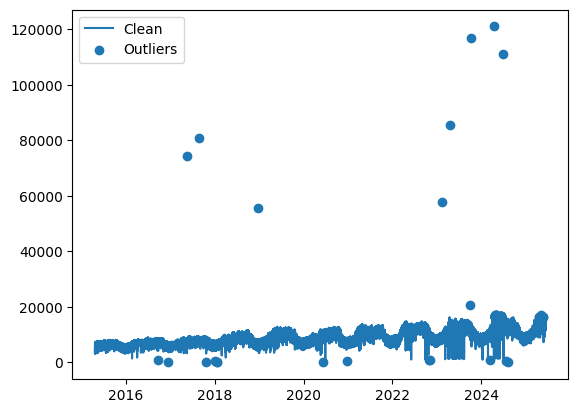

In [ ]:

Q1 = pgcb['demand_mw'].quantile(0.25)
Q3 = pgcb['demand_mw'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
print(f"Lower bound: {lower_bound} | Upper bound: {upper_bound}")

outliers = pgcb[(pgcb['demand_mw'] < lower_bound) |
                (pgcb['demand_mw'] > upper_bound)].copy()

pgcb_clean = pgcb[(pgcb['demand_mw'] >= lower_bound) &
                  (pgcb['demand_mw'] <= upper_bound)].copy()

print(f"\nTotal rows      : {len(pgcb)}")
print(f"Outliers removed: {len(outliers)}")
print(f"Clean rows left : {len(pgcb_clean)}")

plt.plot(pgcb_clean.index, pgcb_clean['demand_mw'], label='Clean')
plt.scatter(outliers.index, outliers['demand_mw'], label='Outliers')
plt.legend()
plt.show()

In [ ]:
pgcb_clean = pgcb_clean.fillna(0)
pgcb_clean = pgcb_clean.reset_index()
weather_clean = weather.reset_index()

# renaming weather time column to match
weather_clean = weather_clean.rename(columns={'time': 'datetime'})

# Both must be sorted for merge_asof
pgcb_clean = pgcb_clean.sort_values('datetime')
weather_clean = weather_clean.sort_values('datetime')

# merge_asof matches nearest timestamp within 30 min
merged = pd.merge_asof(
    pgcb_clean,  weather_clean,   on='datetime',  tolerance=pd.Timedelta('30min'),  direction='nearest'
)

print("Merged shape:", merged.shape)

Merged shape: (89014, 23)


##Filtering only the important axes

In [ ]:
merged['year'] = merged['datetime'].dt.year
relevantIndicators = [
    'NY.GDP.MKTP.KD',        # GDP
    'NY.GDP.PCAP.KD',        # GDP per capita
    'SP.POP.TOTL',           # total population
    'SP.URB.TOTL.IN.ZS',     # urban population %
    'EG.ELC.ACCS.ZS',        # access to electricity %
    'EG.USE.PCAP.KG.OE',     # energy use per capita
    'EG.ELC.LOSS.ZS',        # transmission losses %
    'EG.USE.COMM.FO.ZS',     # fossil fuel consumption %
    'FP.CPI.TOTL',           # consumer price index
    'NV.IND.TOTL.ZS',        # industry value added %
]

# we need to transpose the csv

econ_wide = economic_df[economic_df['Indicator Code'].isin(relevantIndicators)].copy()
year_cols = [col for col in economic_df.columns if str(col).isdigit()]
econ_wide = econ_wide[['Indicator Code'] + year_cols]
econ_t = econ_wide.set_index('Indicator Code')[year_cols].T
econ_t.index = econ_t.index.astype(int)
econ_t.index.name = 'year'
econ_t = econ_t.reset_index()

econ_t = econ_t.fillna(0)

print("Economic indicators shape:", econ_t.shape)

Economic indicators shape: (66, 11)


##Adding concept of rolling and smoothening

In [ ]:
df = merged.copy()

df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()

df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['quarter']     = df.index.quarter
df['is_weekend']  = (df.index.dayofweek >= 5).astype(int)
df['is_night']    = ((df.index.hour >= 22) | (df.index.hour <= 5)).astype(int)
df['hour_sin']    = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']    = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
print("Calendar features done")

# 7B : Lag Features
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    df[f'demand_lag_{lag}h'] = df['demand_mw'].shift(lag)
print("Lag features done")

# 7C : Rolling Features
for w in [3, 6, 12, 24, 168]:
    df[f'demand_roll_mean_{w}h'] = df['demand_mw'].shift(1).rolling(w, min_periods=1).mean()
    df[f'demand_roll_std_{w}h']  = df['demand_mw'].shift(1).rolling(w, min_periods=1).std()
print("✓ Rolling features done")

# Economic merge — using join to preserve datetime index
df['year'] = df.index.year
econ_indexed = econ_t.set_index('year')
df = df.join(econ_indexed, on='year', how='left')
df[econ_indexed.columns] = df[econ_indexed.columns].fillna(0)
print("Economic features merged")

# Target
df['target'] = df['demand_mw'].shift(-1)
df = df.dropna(subset=['target', 'demand_lag_168h'])
print("✓ Target defined")

Calendar features done
Lag features done
✓ Rolling features done
Economic features merged
✓ Target defined


##Making target

In [ ]:

train = df[df.index.year < 2023].copy()
test  = df[df.index.year == 2023].copy()

drop_cols = ['target', 'demand_mw', 'year']
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train = train[feature_cols]
y_train = train['target']

X_test  = test[feature_cols]
y_test  = test['target']

print(f"Training set : {X_train.shape} | {train.index.min().date()} → {train.index.max().date()}")
print(f"Test set     : {X_test.shape}  | {test.index.min().date()} → {test.index.max().date()}")
print(f"Features     : {len(feature_cols)}")

Training set : (67355, 59) | 2015-04-26 → 2022-12-31
Test set     : (8756, 59)  | 2023-01-01 → 2023-12-31
Features     : 59


##Predicting

In [ ]:

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

print("Training model...")
rf_model.fit(X_train, y_train)
print("Training complete")

Training model...
Training complete


##Results

In [ ]:

y_pred = rf_model.predict(X_test)

mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n{'='*40}")
print(f"  MAPE : {mape:.2f}%")
print(f"  MAE  : {mae:.1f} MW")
print(f"  RMSE : {rmse:.1f} MW")
print(f"{'='*40}")


  MAPE : 5.48%
  MAE  : 462.9 MW
  RMSE : 774.6 MW


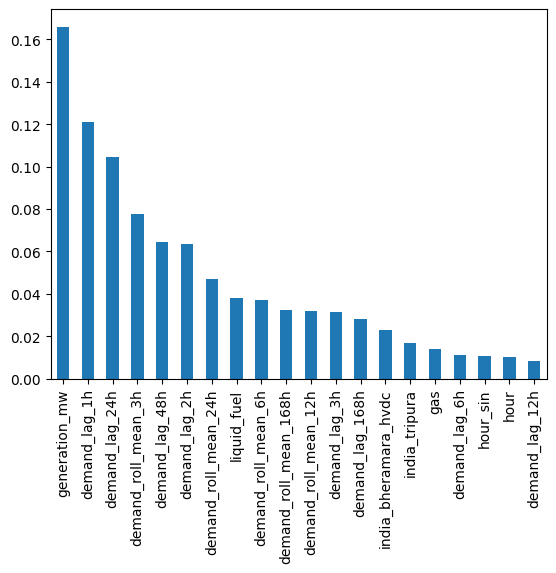

In [ ]:

pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False).head(20).plot.bar()

plt.show()